<a id="top"></a>
# Chapter 7 — Stretching PythTB: butterfly, disorder, quasicrystal, the wall

**PythTB — Tight-Binding Physics from Theory to Code** · Part III — Stretching PythTB · chapter 7 of 8

[◀ 6 Weyl semimetals and the axion angle](PythTB_06_Weyl_and_Axion.ipynb) · [Contents of the book](README.md) · [8 What PythTB cannot do ▶](PythTB_08_What_PythTB_Cannot_Do.ipynb)

**In this chapter**

- [§21 The Hofstadter butterfly — magnetic fields by hand](#sec-21)
- [§22 Disorder — Anderson localization, one eigenvector at a time](#sec-22)
- [§23 A Penrose quasicrystal — order without periodicity](#sec-23)
- [§24 The performance wall — measuring O(N³)](#sec-24)
- [Exercises for Part III](#exercises-III)

All chapters: [0](PythTB_00_Introduction.ipynb) · [1](PythTB_01_Foundations.ipynb) · [2](PythTB_02_Finite_Systems_and_Berry_Phases.ipynb) · [3](PythTB_03_Three_Dimensions_and_Wannier.ipynb) · [4](PythTB_04_Chern_and_Z2.ipynb) · [5](PythTB_05_Higher_Order_and_Kitaev.ipynb) · [6](PythTB_06_Weyl_and_Axion.ipynb) · [7](PythTB_07_Stretching_PythTB.ipynb) · [8](PythTB_08_What_PythTB_Cannot_Do.ipynb) · exercises: [Parts I–II](PythTB_Exercises_I-II.ipynb) · [Parts III–IV](PythTB_Exercises_III-IV.ipynb)

*Every notebook runs on its own: the setup cell below is identical in all of them, and a chapter that reuses a model from an earlier one rebuilds it in a short recap cell. Section numbers (§1–31), figure numbers and cross-references are global to the book.*

In [1]:
# ---- shared setup: this cell is identical in every chapter of the book ----------
import os
import time
import warnings

import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display, HTML

import pythtb
from pythtb import Lattice, TBModel, Mesh, WFArray, Wannier, W90

plt.rcParams.update({
    "figure.dpi": 110,
    "figure.figsize": (7.0, 4.2),
    "axes.grid": True,
    "grid.alpha": 0.3,
    "font.size": 10,
})

# the Wannier90 silicon data (§12) lives in data/ at the repository root
DATA_DIR = next((d for d in ("data", os.path.join("..", "data")) if os.path.isdir(d)), "data")

rng = np.random.default_rng(2026)          # single seed for every stochastic cell

_CHECKS = {"pass": 0, "fail": 0}
_FIG = {"n": 58}               # figure numbers run through the whole book

def check(label, ok, detail=""):
    '''Inline physics check; prints PASS/FAIL and tallies for the final summary.'''
    ok = bool(ok)
    _CHECKS["pass" if ok else "fail"] += 1
    print(f"[{'PASS' if ok else 'FAIL'}] {label}" + (f" — {detail}" if detail else ""))
    return ok

def caption(text):
    '''Numbered caption rendered directly below the figure it describes.'''
    _FIG["n"] += 1
    display(HTML(
        f"<div style='max-width:780px;margin:2px 0 14px 12px;font-size:0.92em;"
        f"color:#444;border-left:3px solid #bbb;padding-left:10px'>"
        f"<b>Figure {_FIG['n']}.</b> {text}</div>"))

def draw_bonds(ax, xy, pairs, color="0.55", lw=1.0, ls="-", zorder=1):
    '''Draw a set of bonds (index pairs) between the 2D points xy on axis ax —
    used throughout to depict the actual system before computing on it.'''
    for i, j in pairs:
        ax.plot(xy[[i, j], 0], xy[[i, j], 1], ls, color=color, lw=lw, zorder=zorder)

print("pythtb", pythtb.__version__, "| numpy", np.__version__, "| chapter 7")
t_chapter_start = time.time()

pythtb 2.0.0 | numpy 2.5.2 | chapter 7


<a id="sec-21"></a>

# Part III — Stretching PythTB

PythTB has no magnetic-field API, no disorder API, no quasicrystal API and no benchmark suite.
This part builds all four out of the primitives — and finds out where the package's pure-Python,
dense-only design starts to hurt.

## 21. The Hofstadter butterfly — magnetic fields by hand

A uniform magnetic field enters a tight-binding model only through **Peierls phases**
$t_{ij} \to t_{ij} e^{i\theta_{ij}}$ with $\sum_{\rm plaquette}\theta = 2\pi\phi$, $\phi$ the flux
per plaquette in quanta. At rational flux $\phi = p/q$ the Hamiltonian is periodic in a $q$-site
**magnetic supercell** (Landau gauge: $x$-dependent phases on $y$-bonds), and the single band of
the square lattice splits into $q$ magnetic subbands. Plotting the spectrum against $\phi$ gives
Hofstadter's 1976 butterfly — a Cantor-set spectrum that took 40 years to reach experiments (moiré
superlattices, 2013).

PythTB supplies no `set_magnetic_field`; the ~10 lines below are the manual construction the
package's design forces — and *permits*: because hoppings are arbitrary complex numbers, gauge
choices are entirely in our hands.

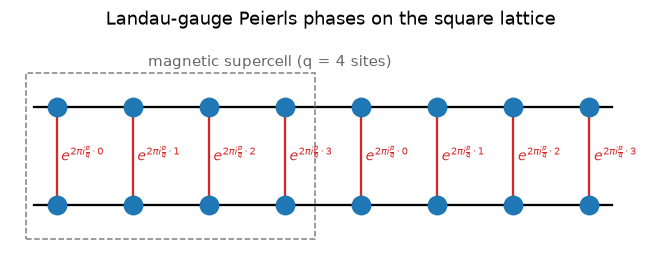

253,584 eigenvalues across 32 denominators in 4.5 s — all dense, all Python


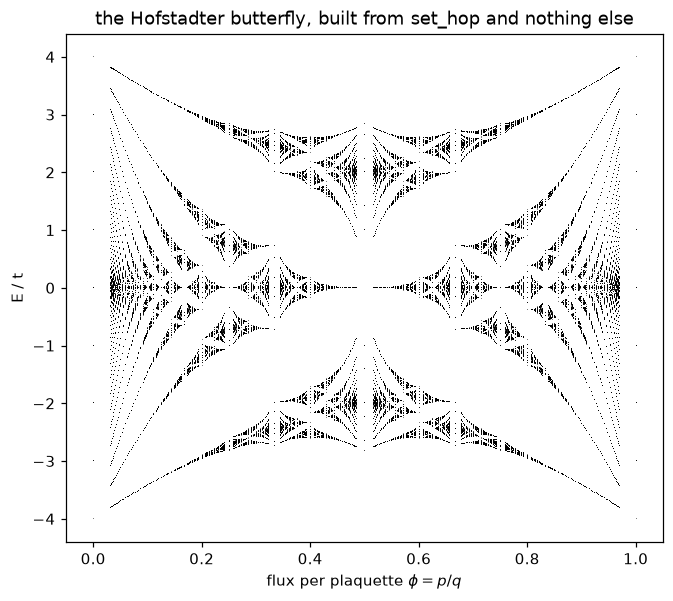

In [2]:
from math import gcd

def hofstadter_model(p, q, t=1.0):
    '''Square lattice at flux p/q per plaquette: q-site magnetic supercell along x,
    Landau gauge (phases on y-bonds, proportional to the x position).'''
    lat = Lattice(lat_vecs=[[q, 0], [0, 1]],
                  orb_vecs=[[i / q, 0] for i in range(q)], periodic_dirs=[0, 1])
    m = TBModel(lat)
    for i in range(q):
        m.set_hop(-t, i, (i + 1) % q, [1 if i == q - 1 else 0, 0])       # x bonds
        m.set_hop(-t * np.exp(2j * np.pi * p / q * i), i, i, [0, 1])     # y bonds
    return m

# the construction, drawn: a q-site magnetic supercell in Landau gauge — plain
# hops along x, x-dependent phases on the y bonds
q_demo = 4
fig, ax = plt.subplots(figsize=(7.5, 2.6))
for iy in range(2):
    for ix in range(2 * q_demo):
        ax.plot([ix], [iy], "o", ms=12, color="C0", zorder=3)
        if iy == 0:
            ax.plot([ix, ix], [0, 1], "-", color="C3", lw=1.5)
            ax.annotate(rf"$e^{{2\pi i \frac{{p}}{{q}} \cdot {ix % q_demo}}}$",
                        (ix + 0.06, 0.45), fontsize=9, color="C3")
    ax.plot([-0.3, 2 * q_demo - 0.7], [iy, iy], "-", color="k", lw=1.5, zorder=1)
ax.add_patch(plt.Rectangle((-0.4, -0.35), q_demo - 0.2, 1.7, fill=False, ls="--", ec="0.5"))
ax.annotate(f"magnetic supercell (q = {q_demo} sites)", (1.2, 1.42), fontsize=10, color="0.4")
ax.set_xlim(-0.6, 2 * q_demo - 0.2); ax.set_ylim(-0.5, 1.75)
ax.axis("off")
ax.set_title("Landau-gauge Peierls phases on the square lattice")
plt.show()
caption("How a uniform field enters a lattice model: hoppings along x stay real "
        "(black), hoppings along y acquire the Peierls phase exp(2πi·(p/q)·x) that "
        "grows with the column index (red labels). The pattern repeats after q "
        "columns — the magnetic supercell (dashed box) — which is why rational "
        "flux p/q restores Bloch's theorem with a q-site cell and q subbands.")
Q_MAX = 32
t0 = time.time()
phi_pts, E_pts = [], []
for q in range(1, Q_MAX + 1):
    for p in range(q + 1):
        if gcd(p, q) != 1 and not (p == 0 and q == 1):
            continue
        hm = hofstadter_model(p, q)
        ev = hm.solve_ham(hm.k_uniform_mesh([6, 6], include_endpoints=False))
        phi_pts.append(np.full(ev.size, p / q))
        E_pts.append(ev.ravel())
phi_all = np.concatenate(phi_pts)
E_all = np.concatenate(E_pts)
print(f"{len(phi_all):,} eigenvalues across {Q_MAX} denominators "
      f"in {time.time()-t0:.1f} s — all dense, all Python")

fig, ax = plt.subplots(figsize=(7, 6))
ax.plot(phi_all, E_all, ",", color="k", alpha=0.5)
ax.set_xlabel(r"flux per plaquette $\phi = p/q$")
ax.set_ylabel("E / t")
ax.set_title("the Hofstadter butterfly, built from set_hop and nothing else")
ax.grid(False)
plt.show()
caption("The Hofstadter butterfly: every eigenvalue of the square lattice at "
        "every rational flux p/q with q ≤ 32. The spectrum is a Cantor set — the "
        "pattern inside any gap-bounded wing repeats the whole. Each gap carries a "
        "quantized Hall conductance (the Diophantine labels of exercise III.1), "
        "and the giant central gaps at simple fractions are the ones seen in moiré "
        "superlattice experiments.")

In [3]:
# two exact symmetries of the butterfly, as checks
ev_half = np.sort(hofstadter_model(1, 2).solve_ham(
    hofstadter_model(1, 2).k_uniform_mesh([20, 20])).ravel())
check("phi=1/2 spectrum is particle-hole symmetric",
      np.allclose(ev_half, -ev_half[::-1], atol=1e-10))

ev_a = np.sort(hofstadter_model(1, 5).solve_ham(
    hofstadter_model(1, 5).k_uniform_mesh([15, 15])).ravel())
ev_b = np.sort(hofstadter_model(4, 5).solve_ham(
    hofstadter_model(4, 5).k_uniform_mesh([15, 15])).ravel())
check("phi -> 1 - phi symmetry (time reversal of the field)",
      np.allclose(ev_a, ev_b, atol=1e-10),
      f"max dev = {np.abs(ev_a - ev_b).max():.1e}")

# and the q-subband structure: flux 1/3 must show exactly 3 magnetic subbands
ev3 = hofstadter_model(1, 3).solve_ham(hofstadter_model(1, 3).k_uniform_mesh([40, 40]))
gaps = [ev3[:, b + 1].min() - ev3[:, b].max() for b in range(2)]
check("phi=1/3: three subbands separated by open gaps",
      all(g > 0.1 for g in gaps), f"gaps = {[f'{g:.3f}' for g in gaps]}")

[PASS] phi=1/2 spectrum is particle-hole symmetric
[PASS] phi -> 1 - phi symmetry (time reversal of the field) — max dev = 2.7e-15
[PASS] phi=1/3: three subbands separated by open gaps — gaps = ['1.293', '1.268']


True

<a id="sec-22"></a>

## 22. Disorder — Anderson localization, one eigenvector at a time

Disorder breaks Bloch's theorem, so every k-space tool in this notebook goes dark; what remains is
exact diagonalization of finite samples. PythTB handles this without complaint — a disordered
sample is just `set_onsite` with random values — but with **dense** diagonalization only, the
accessible sizes stop near $10^3$–$10^4$ orbitals (§24 quantifies the wall; Kwant's sparse solvers
and KPM push to $10^6$+).

Diagnostic: the **inverse participation ratio** $\mathrm{IPR} = \sum_i |\psi_i|^4$ — of order
$1/N$ for an extended state, of order $1/\xi^2$ (size-independent) for a state localized on $\xi^2$
sites. In 2D all states localize for any $W$, but at weak disorder $\xi$ vastly exceeds our sample
— finite-size physics we can *see* directly.

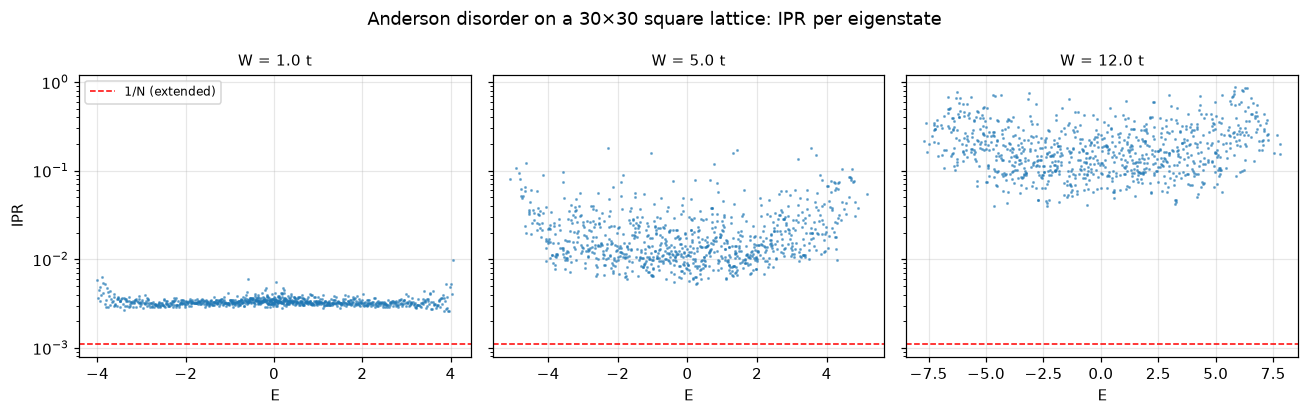

[PASS] IPR grows monotonically with disorder strength — mean IPR: 0.0033 → 0.0221 → 0.2099


True

In [4]:
L = 30                                                # 900 sites
lat_sq = Lattice(lat_vecs=[[1, 0], [0, 1]], orb_vecs=[[0, 0]], periodic_dirs=[0, 1])
sq = TBModel(lat_sq)
sq.set_hop(-1.0, 0, 0, [1, 0])
sq.set_hop(-1.0, 0, 0, [0, 1])
box = sq.make_finite(periodic_dirs=[0, 1], num_cells=[L, L])

fig, axs = plt.subplots(1, 3, figsize=(12, 3.8), sharey=True)
ipr_mean = {}
for ax, W in zip(axs, (1.0, 5.0, 12.0)):
    dis = box.copy()
    dis.set_onsite(list(rng.uniform(-W / 2, W / 2, box.norb)), mode="reset")
    ev, vec = dis.solve_ham(return_eigvecs=True)
    ipr = np.sum(np.abs(vec) ** 4, axis=1)
    ax.semilogy(ev, ipr, ".", ms=2, alpha=0.5)
    ax.axhline(1 / box.norb, color="r", ls="--", lw=1, label="1/N (extended)")
    ax.set_title(f"W = {W} t", fontsize=10)
    ax.set_xlabel("E")
    ipr_mean[W] = ipr.mean()
axs[0].set_ylabel("IPR")
axs[0].legend(loc="upper left", fontsize=8)
fig.suptitle(f"Anderson disorder on a {L}×{L} square lattice: IPR per eigenstate")
fig.tight_layout()
plt.show()
caption("Inverse participation ratio of every eigenstate of a disordered "
        "square-lattice box, for three disorder strengths. At W = t most states "
        "hug the extended-state line 1/N (dashed red) — their localization length "
        "exceeds the sample. As W grows the whole spectrum lifts off by orders of "
        "magnitude, band-edge states first: localization sets in from the spectral "
        "edges inward, the standard mobility-edge phenomenology compressed into a "
        "30×30 box.")

check("IPR grows monotonically with disorder strength",
      ipr_mean[1.0] < ipr_mean[5.0] < ipr_mean[12.0],
      f"mean IPR: {ipr_mean[1.0]:.4f} → {ipr_mean[5.0]:.4f} → {ipr_mean[12.0]:.4f}")

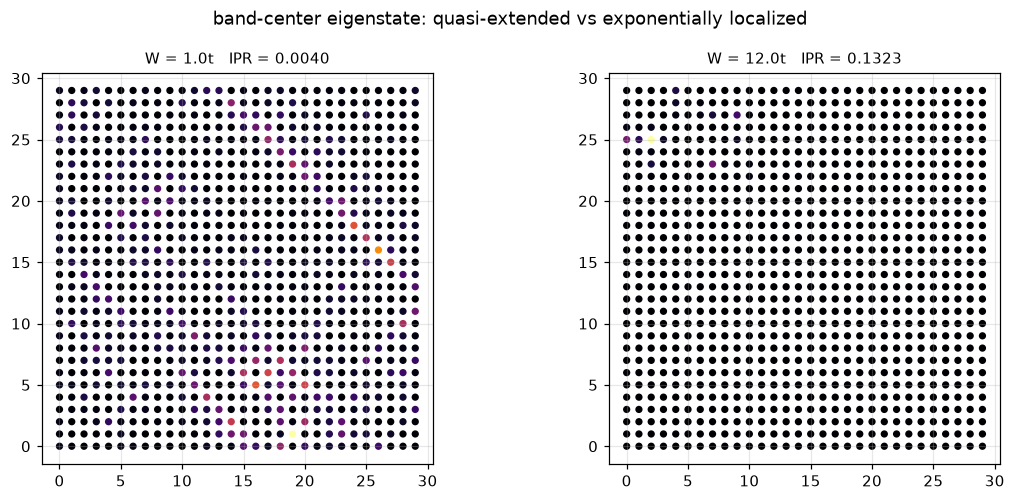

In [5]:
# what localization looks like: one mid-band eigenstate at weak vs strong disorder
fig, axs = plt.subplots(1, 2, figsize=(10.5, 4.6))
for ax, W in zip(axs, (1.0, 12.0)):
    dis = box.copy()
    rng_W = np.random.default_rng(7)                   # same realization pattern
    dis.set_onsite(list(rng_W.uniform(-W / 2, W / 2, box.norb)), mode="reset")
    ev, vec = dis.solve_ham(return_eigvecs=True)
    i_mid = np.argmin(np.abs(ev))                      # state nearest band center
    dens = np.abs(vec[i_mid]) ** 2
    pos = dis.orb_vecs @ dis.lat_vecs
    sc = ax.scatter(pos[:, 0], pos[:, 1], c=dens, s=14, cmap="inferno")
    ax.set_aspect("equal")
    ax.set_title(f"W = {W}t   IPR = {np.sum(dens**2):.4f}", fontsize=10)
fig.suptitle("band-center eigenstate: quasi-extended vs exponentially localized")
fig.tight_layout()
plt.show()
caption("One band-center eigenstate at weak (left) and strong (right) disorder, "
        "|ψ|² on the actual lattice. The weak-disorder state still spreads over "
        "the whole box in an irregular interference pattern; the strong-disorder "
        "state has collapsed onto a few sites around one favourable potential "
        "fluctuation. In 2D the left state IS localized too — its ξ merely exceeds "
        "the box, a distinction our finite sample cannot resolve, and (§24) dense "
        "diagonalization cannot push much further.")

<a id="sec-23"></a>

## 23. A Penrose quasicrystal — order without periodicity

Quasicrystals have no unit cell at all, yet perfect long-range order. The Penrose rhombus tiling
(five-fold symmetric, built here with **de Bruijn's pentagrid dual method**, 1981) is the canonical
2D example. PythTB accommodates it like any finite cluster: a `dim_k = 0` point cloud with
hops on the rhombus edges — Bloch's theorem is nowhere involved.

The tight-binding physics is famous in its own right: the rhombus graph is bipartite, and a finite
fraction of all eigenstates are **strictly confined states** piled up at exactly $E = 0$ —
destructive-interference states living on a handful of vertices, first analyzed by
Kohmoto–Sutherland (1986); in the infinite tiling their fraction is exactly
$81 - 50\varphi \approx 0.098$ (φ the golden ratio). A macroscopic degeneracy demanded by
*aperiodic* order — our check below measures it.

Penrose patch: 677 vertices
677 orbitals, 1299 bonds


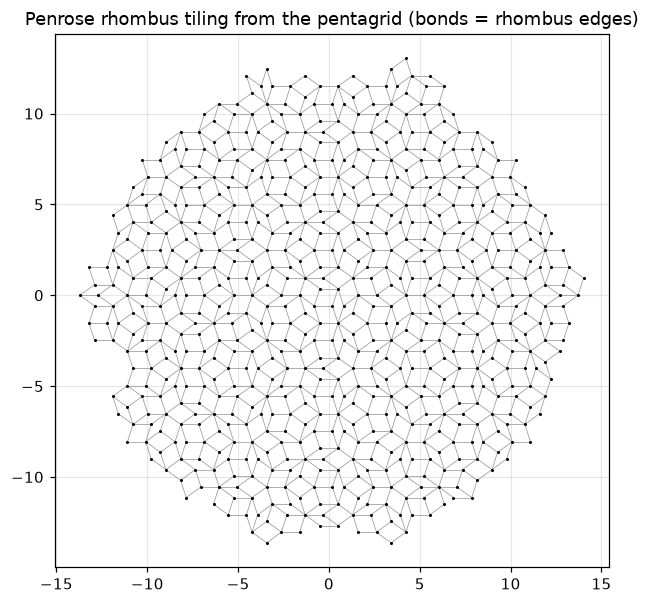

In [6]:
# de Bruijn pentagrid -> Penrose tiling vertices
def penrose_vertices(n_range=6, gammas=None):
    '''Vertices of the Penrose rhombus tiling via the pentagrid dual method.'''
    if gammas is None:
        g = np.array([0.13, 0.27, 0.41, 0.08, 0.11])
        gammas = g - g.sum() / 5 + 1 / 5 * 0            # generic offsets
    e = np.array([[np.cos(2 * np.pi * k / 5), np.sin(2 * np.pi * k / 5)]
                  for k in range(5)])
    verts = {}
    ns = np.arange(-n_range, n_range + 1)
    for k1 in range(5):
        for k2 in range(k1 + 1, 5):
            det = e[k1, 0] * e[k2, 1] - e[k1, 1] * e[k2, 0]
            for n1 in ns:
                for n2 in ns:
                    # intersection of grid lines e_k1.x = n1+g1, e_k2.x = n2+g2
                    b1, b2 = n1 + gammas[k1], n2 + gammas[k2]
                    x = np.array([b1 * e[k2, 1] - b2 * e[k1, 1],
                                  b2 * e[k1, 0] - b1 * e[k2, 0]]) / det
                    if np.linalg.norm(x) > n_range * 0.85:
                        continue
                    K = np.ceil(e @ x - gammas - 1e-12)
                    K[k1], K[k2] = n1, n2               # on the lines themselves
                    # the four rhombus corners dual to this intersection
                    for d1 in (0, 1):
                        for d2 in (0, 1):
                            Kd = K.copy()
                            Kd[k1] += d1
                            Kd[k2] += d2
                            v = Kd @ e
                            verts[tuple(np.round(v, 6))] = True
    return np.array(list(verts.keys()))

xy_pen = penrose_vertices(n_range=6)
print(f"Penrose patch: {len(xy_pen)} vertices")

# tight-binding on the rhombus edges (all edges have unit length; the rhombus
# diagonals are 0.618, 1.176, 1.618, 1.902 — a pure distance filter is exact)
def cloud_nn_model(xy, t=1.0, d_bond=1.0, tol=1e-4):
    span = np.abs(xy).max() * 2 + 2
    lat = Lattice(lat_vecs=np.eye(2) * span, orb_vecs=(xy - xy.min(0)) / span,
                  periodic_dirs=[])
    m = TBModel(lat)
    d2 = np.sum((xy[:, None, :] - xy[None, :, :]) ** 2, axis=-1)
    ii, jj = np.where(np.abs(d2 - d_bond ** 2) < tol)
    for i, j in zip(ii, jj):
        if i < j:
            m.set_hop(-t, int(i), int(j), mode="set")
    return m

pen = cloud_nn_model(xy_pen)
print(f"{pen.norb} orbitals, {pen.nhops} bonds")

fig, ax = plt.subplots(figsize=(6.5, 6.5))
d2 = np.sum((xy_pen[:, None, :] - xy_pen[None, :, :]) ** 2, axis=-1)
ii, jj = np.where(np.abs(d2 - 1.0) < 1e-4)
for i, j in zip(ii, jj):
    if i < j:
        ax.plot(xy_pen[[i, j], 0], xy_pen[[i, j], 1], "-", color="0.6", lw=0.5)
ax.plot(xy_pen[:, 0], xy_pen[:, 1], "k.", ms=2)
ax.set_aspect("equal")
ax.set_title("Penrose rhombus tiling from the pentagrid (bonds = rhombus edges)")
plt.show()
caption("A Penrose tiling patch generated by de Bruijn's pentagrid construction: "
        "fat and thin rhombi, all edges of unit length, five-fold orientational "
        "order and no repeating cell anywhere. This is a legitimate PythTB model — "
        "a dim_k = 0 point cloud with hops on the rhombus edges — because nothing "
        "in the package's data model actually requires periodicity.")

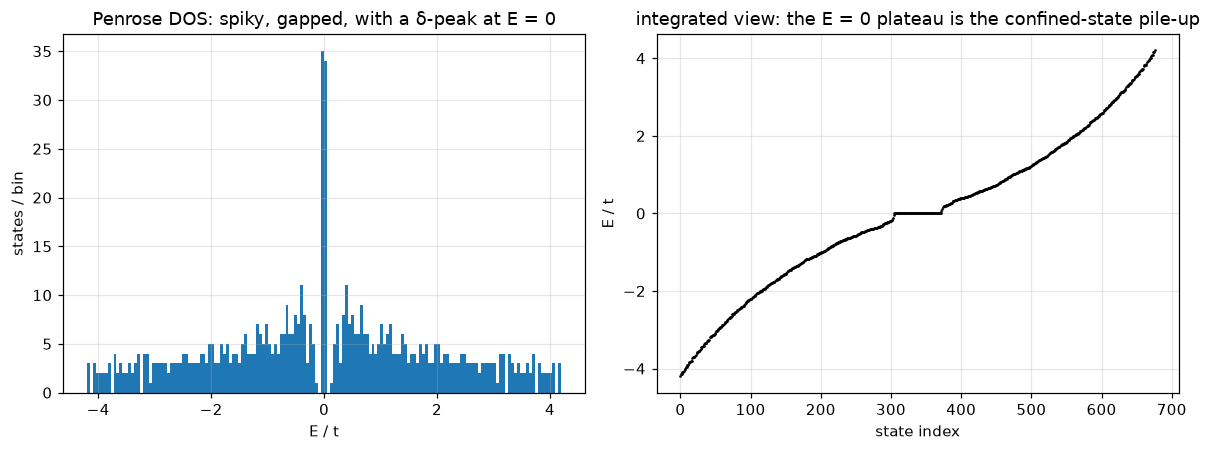

[PASS] bipartite rhombus graph: spectrum symmetric under E -> -E
[PASS] confined-state fraction near the exact 81 - 50φ ≈ 0.098 — measured 0.0990 vs exact 0.0983 (boundary corrections at this size)


True

In [7]:
# spectrum: bipartite symmetry + the macroscopic E = 0 degeneracy
ev_pen, vec_pen = pen.solve_ham(return_eigvecs=True)

fig, axs = plt.subplots(1, 2, figsize=(11, 4.2))
axs[0].hist(ev_pen, bins=160, color="C0")
axs[0].set_xlabel("E / t"); axs[0].set_ylabel("states / bin")
axs[0].set_title("Penrose DOS: spiky, gapped, with a δ-peak at E = 0")
axs[1].plot(np.arange(len(ev_pen)), np.sort(ev_pen), "k.", ms=1.5)
axs[1].set_xlabel("state index"); axs[1].set_ylabel("E / t")
axs[1].set_title("integrated view: the E = 0 plateau is the confined-state pile-up")
fig.tight_layout()
plt.show()
caption("Left: the Penrose density of states — spiky, riddled with gaps, and "
        "carrying a δ-function at E = 0. Right: the sorted spectrum, where that "
        "δ-peak appears as a plateau of ~10% of all states at exactly zero energy: "
        "the strictly confined states, destructive-interference eigenstates that "
        "aperiodic order produces in macroscopic number (fraction 81 − 50φ in the "
        "infinite tiling).")

ev_s = np.sort(ev_pen)
check("bipartite rhombus graph: spectrum symmetric under E -> -E",
      np.allclose(ev_s, -ev_s[::-1], atol=1e-10))

frac0 = np.mean(np.abs(ev_pen) < 1e-8)
phi_g = (1 + np.sqrt(5)) / 2
frac_exact = 81 - 50 * phi_g
check("confined-state fraction near the exact 81 - 50φ ≈ 0.098",
      abs(frac0 - frac_exact) < 0.03,
      f"measured {frac0:.4f} vs exact {frac_exact:.4f} (boundary corrections at this size)")

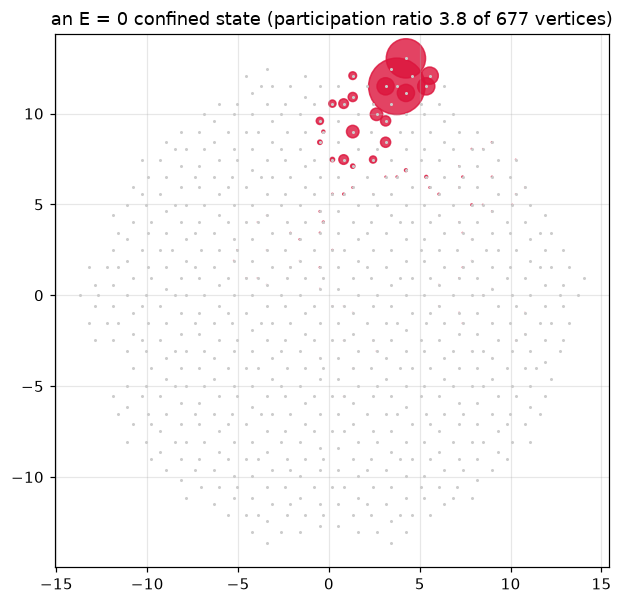

[PASS] confined state is interference-localized on a handful of vertices — participation ratio 3.8 (vs 238 for a generic state); top-20 sites hold 99.2%


True

In [8]:
# a confined state: strictly zero outside a few vertices.
# NB: eigh returns an ARBITRARY orthogonal basis of the huge E=0 degenerate
# subspace — generic members are spread over the whole patch. To exhibit a
# confined state, project a single-site seed onto the kernel: P0|i> is again
# a zero mode, and it inherits the finite support of the confined states
# overlapping site i.
zero_idx = np.where(np.abs(ev_pen) < 1e-8)[0]
V0 = vec_pen[zero_idx]                                  # (n0, N) kernel basis
w_site = np.sum(np.abs(V0) ** 2, axis=0)                # kernel weight per site
i_seed = int(np.argmax(w_site))                         # site where the kernel is most local
psi0 = V0.conj().T @ V0[:, i_seed]                      # P0 |i_seed>
psi0 = psi0 / np.linalg.norm(psi0)
dens0 = np.abs(psi0) ** 2
PR = 1 / np.sum(dens0 ** 2)                             # participation ratio

fig, ax = plt.subplots(figsize=(6.5, 6.5))
ax.plot(xy_pen[:, 0], xy_pen[:, 1], ".", color="0.8", ms=2)
big = dens0 > 1e-6
ax.scatter(xy_pen[big, 0], xy_pen[big, 1], s=3000 * dens0[big], c="crimson", alpha=0.8)
ax.set_aspect("equal")
ax.set_title(f"an E = 0 confined state (participation ratio {PR:.1f} of {pen.norb} vertices)")
plt.show()
caption("One confined state, extracted from the huge E = 0 degenerate subspace "
        "by projecting a single-site seed onto it: over 99% of its weight lives on "
        "a handful of vertices (red), strictly protected by interference — the "
        "amplitudes cancel on every site bordering the support. Unlike Anderson "
        "localization there is no exponential tail to speak of and no disorder: "
        "this is localization by geometry.")

i_typ = np.argmin(np.abs(ev_pen - 1.0))                 # a generic E ≈ t state
PR_typ = 1 / np.sum(np.abs(vec_pen[i_typ]) ** 4)
check("confined state is interference-localized on a handful of vertices",
      PR < 10 and np.sort(dens0)[::-1][:20].sum() > 0.95,
      f"participation ratio {PR:.1f} (vs {PR_typ:.0f} for a generic state); "
      f"top-20 sites hold {100*np.sort(dens0)[::-1][:20].sum():.1f}%")

<a id="sec-24"></a>

## 24. The performance wall — measuring O(N³)

Everything PythTB computes routes through `numpy.linalg.eigh`-class dense diagonalization: cost
$O(N^3)$ time and $O(N^2)$ memory per k-point (or per sample). That is a *design choice* — for
band-structure pedagogy $N$ is tens, and dense is simple and exact. But it defines the boundary of
the possible: below we time it, fit the exponent, and then show what PythTB *could not* give us —
a few eigenstates of a big system — by exporting the very same Hamiltonian to a sparse solver.

That export is the honest verdict of this section: `hamiltonian()` hands you the dense matrix, so
nothing stops *you* from going sparse — but at that point PythTB has reduced itself to a model
*builder*, and every solver convenience (bands, Berry phases, markers) is left behind.

N =   100   dense full spectrum:      3.5 ms
N =   200   dense full spectrum:     17.5 ms


N =   400   dense full spectrum:    111.2 ms


N =   800   dense full spectrum:    448.8 ms


N =  1600   dense full spectrum:   2136.0 ms


N =  3200   dense full spectrum:  11893.2 ms


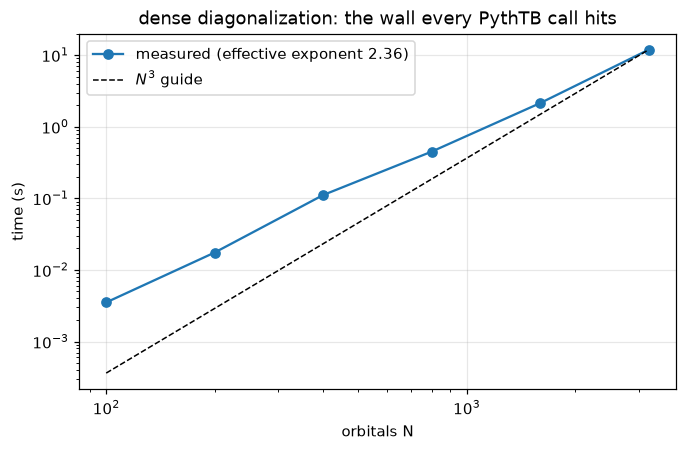

[PASS] dense solve wall-time grows superquadratically toward the N^3 asymptote — effective log-log exponent = 2.36


True

In [9]:
import scipy.sparse as sp
import scipy.sparse.linalg as spla

sizes = [100, 200, 400, 800, 1600, 3200]
t_dense = []
chain1d = TBModel(Lattice(lat_vecs=[[1.0]], orb_vecs=[[0.0]], periodic_dirs=[0]))
chain1d.set_hop(-1.0, 0, 0, [1])
for N in sizes:
    fin = chain1d.cut_piece(N, 0)
    t0 = time.time()
    fin.solve_ham()
    t_dense.append(time.time() - t0)
    print(f"N = {N:5d}   dense full spectrum: {t_dense[-1]*1000:8.1f} ms")

slope = np.polyfit(np.log(sizes[-3:]), np.log(t_dense[-3:]), 1)[0]
fig, ax = plt.subplots()
ax.loglog(sizes, t_dense, "o-", label=f"measured (effective exponent {slope:.2f})")
ax.loglog(sizes, np.array(sizes, float) ** 3 * t_dense[-1] / sizes[-1] ** 3,
          "k--", lw=1, label=r"$N^3$ guide")
ax.set_xlabel("orbitals N"); ax.set_ylabel("time (s)")
ax.legend(); ax.set_title("dense diagonalization: the wall every PythTB call hits")
plt.show()
caption("Wall time of a full dense diagonalization versus matrix size, log-log, "
        "with the ideal N³ slope as a guide. The measured effective exponent sits "
        "below 3 in this range only because threaded BLAS gains efficiency as "
        "matrices grow; the asymptote is inescapable. Every quantity PythTB "
        "computes — bands, Berry phases, markers, Wannier functions — stands on "
        "this staircase.")
# the algorithm is O(N^3) in flops; measured WALL-TIME exponents in this window sit
# below 3 because threaded BLAS keeps gaining efficiency with matrix size — the
# wall is real, it just arrives with a sub-cubic-looking run-up
check("dense solve wall-time grows superquadratically toward the N^3 asymptote",
      2.0 < slope < 3.7, f"effective log-log exponent = {slope:.2f}")

In [10]:
# the same Hamiltonian, exported: sparse Lanczos for a few states of a BIG system
N_big = 6000
fin_big = chain1d.cut_piece(N_big, 0)
t0 = time.time()
H_big = sp.csr_matrix(fin_big.hamiltonian())          # PythTB still builds it dense!
t_build = time.time() - t0
t0 = time.time()
ev_sparse = spla.eigsh(H_big, k=6, sigma=0.0, return_eigenvectors=False)
t_sparse = time.time() - t0
print(f"N = {N_big:,}: H exported DENSE in {t_build:.1f} s and {8*2*N_big**2/1e9:.2f} GB "
      f"(PythTB has no sparse assembly), then 6 states near E=0 in {t_sparse:.1f} s")
print("6 eigenvalues nearest 0:", np.round(np.sort(ev_sparse), 6))

# analytic: open chain evals are -2t cos(pi m /(N+1)) — check the sparse result
m_grid = np.arange(1, N_big + 1)
exact = np.sort(-2 * np.cos(np.pi * m_grid / (N_big + 1)))
nearest = exact[np.argsort(np.abs(exact))[:6]]
check("sparse eigenvalues match the analytic open-chain spectrum",
      np.allclose(np.sort(ev_sparse), np.sort(nearest), atol=1e-8),
      f"max dev = {np.abs(np.sort(ev_sparse) - np.sort(nearest)).max():.1e}")
est_dense = t_dense[-1] * (N_big / sizes[-1]) ** 3
print(f"extrapolated dense full solve at N = {N_big:,}: ~{est_dense/60:.0f} minutes "
      f"and ~{8 * N_big**2 * 2 / 1e9:.1f} GB — the wall, quantified")

N = 6,000: H exported DENSE in 1.7 s and 0.58 GB (PythTB has no sparse assembly), then 6 states near E=0 in 0.1 s
6 eigenvalues nearest 0: [-0.002618 -0.001571 -0.000524  0.000524  0.001571  0.002618]
[PASS] sparse eigenvalues match the analytic open-chain spectrum — max dev = 3.5e-16
extrapolated dense full solve at N = 6,000: ~1 minutes and ~0.6 GB — the wall, quantified


<a id="exercises-III"></a>

## Exercises for Part III

Worked solutions are in `PythTB_Exercises_Solutions.ipynb`.

**III.1 — Colored butterfly.** For $q \le 8$, compute the Chern number of each Hofstadter gap
(sum the subband Chern numbers below it with `WFArray.chern_number` on the magnetic supercell) and
verify the Diophantine equation $p\,C_r + q\,s_r = r$ for the $r$-th gap.

**III.2 — Butterfly on other lattices.** Repeat §21 for the triangular and honeycomb lattices.
The honeycomb butterfly at small flux contains the relativistic Landau levels
$E_n \propto \sqrt{n B}$ — extract the $\sqrt{B}$ law from your data.

**III.3 — Localization length.** For the 1D Anderson chain, compute the localization length at
band center from the decay of the transmission... which PythTB cannot compute. Instead, extract
$\xi(W)$ from the exponential decay of mid-band eigenstates in chains of length $4\xi$, and verify
the perturbative law $\xi \approx 96\,t^2/W^2$ (in sites) at weak disorder.

**III.4 — Ammann–Beenker.** Build the 8-fold Ammann–Beenker quasicrystal by cut-and-project from
$\mathbb{Z}^4$ and compare its E = 0 confined-state fraction with the Penrose value.

In [11]:
# ---- tally for this notebook ---------------------------------------------------
print("=" * 66)
print(f"chapter 7 — checks passed : {_CHECKS['pass']}")
print(f"chapter 7 — checks failed : {_CHECKS['fail']}")
print(f"wall time                 : {time.time() - t_chapter_start:.0f} s")
print("=" * 66)
print("Every quantitative claim in this notebook was verified in this run."
      if _CHECKS["fail"] == 0 else "Some checks FAILED — search this notebook for '[FAIL]'.")

chapter 7 — checks passed : 9
chapter 7 — checks failed : 0
wall time                 : 43 s
Every quantitative claim in this notebook was verified in this run.
